# Алгоритмы Монтгомери в кольце вычетов ℤ_N

Демонстрация реализации из `montgomery.py`: умножение по модулю, умножение по Монтгомери и возведение в степень.

Вместо деления на произвольный модуль *N* вычисления ведутся по модулю *R = bⁿ* (деление на *R* — сдвиг).
Отображение φ_R(x) = xR⁻¹ mod N — изоморфизм колец (ℤ_N; +, ×) → (ℤ_N; +, ∗), где x∗y = xyR⁻¹ mod N.

In [1]:
import random, time
import matplotlib.pyplot as plt
from montgomery import Montgomery, montgomery_pow, montgomery_mul

## 1. Параметры алгоритма
Для N = 1 000 000 007 и b = 2: R = 2ⁿ, где n — длина N в двоичной записи; R·R′ − N·N′ = 1.

In [2]:
N = 1_000_000_007
M = Montgomery(N, b=2)
print("n  =", M.n)
print("R  =", M.R)
print("R' =", M.Rinv, "  (R^-1 mod N)")
print("N' =", M.Np,   "  (-N^-1 mod R)")
print("R*R' - N*N' =", M.R * M.Rinv - N * M.Np)

n  = 30
R  = 1073741824
R' = 73699066   (R^-1 mod N)
N' = 79133769   (-N^-1 mod R)
R*R' - N*N' = 1


## 2. Алгоритм 1 (редукция) и алгоритм 2 (произведение)

In [3]:
x, y = 123456789, 987654321
print("redc(x*y)         =", M.redc(x * y))
print("mont_product(x,y) =", M.mont_product(x, y))
print("x*y*R^-1 mod N    =", x * y * M.Rinv % N)

redc(x*y)         = 368822163
mont_product(x,y) = 368822163
x*y*R^-1 mod N    = 368822163


## 3. Умножение по модулю и умножение по Монтгомери

In [4]:
print("mul_mod :", M.mul_mod(x, y), "| x*y mod N   :", x * y % N)
print("mont_mul:", M.mont_mul(x, y), "| x*y*R mod N :", x * y * M.R % N)
a = M.to_mont(x)
print("to_mont/from_mont возвращают x:", M.from_mont(a) == x)

mul_mod : 259106859 | x*y mod N   : 259106859
mont_mul: 446073733 | x*y*R mod N : 446073733
to_mont/from_mont возвращают x: True


## 4. Возведение в степень

In [5]:
for k in (0, 1, 2, 10, 10**6, 10**18):
    r = M.pow_mod(5, k)
    print(f"5^{k} mod N = {r}  | совпадает с pow: {r == pow(5, k, N)}")

5^0 mod N = 1  | совпадает с pow: True
5^1 mod N = 5  | совпадает с pow: True
5^2 mod N = 25  | совпадает с pow: True
5^10 mod N = 9765625  | совпадает с pow: True
5^1000000 mod N = 668655281  | совпадает с pow: True
5^1000000000000000000 mod N = 921116510  | совпадает с pow: True


In [6]:
p = 2**127 - 1   # простое число Мерсенна
print("Малая теорема Ферма, a^(p-1) mod p =", montgomery_pow(123456789, p - 1, p))

Малая теорема Ферма, a^(p-1) mod p = 1


## 5. Проверка на случайных данных
Сравнение со встроенным `pow(x, k, N)` для разных оснований b.

In [7]:
from math import gcd
rnd = random.Random(42)
checked = 0
for b in (2, 3, 10, 16, 256, 2**16):
    for _ in range(200):
        N_ = rnd.randrange(3, 2**256)
        if gcd(N_, b) != 1: continue
        Mx = Montgomery(N_, b)
        x_, y_, k_ = rnd.randrange(N_), rnd.randrange(N_), rnd.randrange(1000)
        assert Mx.mul_mod(x_, y_) == x_ * y_ % N_
        assert Mx.pow_mod(x_, k_) == pow(x_, k_, N_)
        checked += 1
print("Проверено случайных наборов:", checked, "— все совпали")

Проверено случайных наборов: 591 — все совпали


## 6. Сложность

**Линейное vs бинарное возведение.** Линейный вариант делает *k − 1* умножений — O(k·n²), бинарный — O(log k · n²).

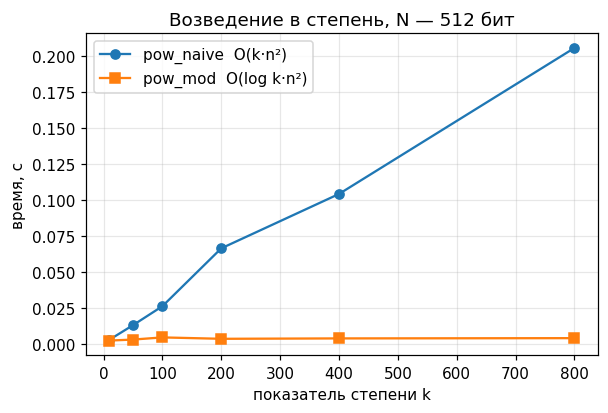

In [8]:
N512 = random.Random(1).getrandbits(512) | 1 | (1 << 511)
M512 = Montgomery(N512)
x512 = 3**300
ks = [10, 50, 100, 200, 400, 800]
t_naive, t_bin = [], []
for k in ks:
    t = time.perf_counter(); M512.pow_naive(x512, k); t_naive.append(time.perf_counter() - t)
    t = time.perf_counter(); M512.pow_mod(x512, k);   t_bin.append(time.perf_counter() - t)

plt.figure(figsize=(6, 3.8))
plt.plot(ks, t_naive, "o-", label="pow_naive  O(k·n²)")
plt.plot(ks, t_bin, "s-", label="pow_mod  O(log k·n²)")
plt.xlabel("показатель степени k"); plt.ylabel("время, с")
plt.title("Возведение в степень, N — 512 бит"); plt.legend(); plt.grid(alpha=.3)
plt.show()

**Рост от длины модуля.** Одно произведение стоит O(n²), поэтому время `mont_product` растёт квадратично по длине N.

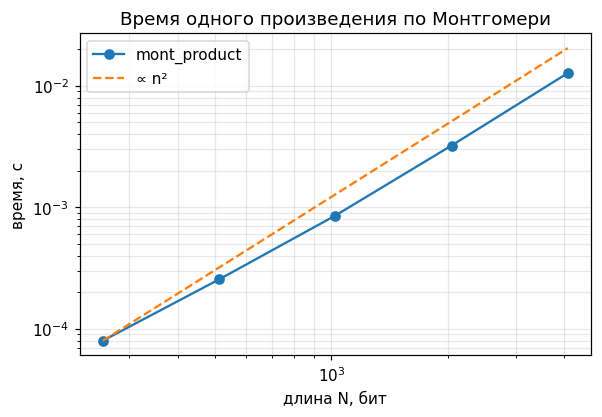

In [9]:
bits_list = [256, 512, 1024, 2048, 4096]
times = []
rnd = random.Random(3)
for bits in bits_list:
    N_ = rnd.getrandbits(bits) | 1 | (1 << (bits - 1))
    Mb = Montgomery(N_)
    x_, y_ = rnd.randrange(N_), rnd.randrange(N_)
    reps = 20
    t = time.perf_counter()
    for _ in range(reps): Mb.mont_product(x_, y_)
    times.append((time.perf_counter() - t) / reps)

plt.figure(figsize=(6, 3.8))
plt.loglog(bits_list, times, "o-", label="mont_product")
plt.loglog(bits_list, [times[0] * (b / bits_list[0]) ** 2 for b in bits_list], "--", label="∝ n²")
plt.xlabel("длина N, бит"); plt.ylabel("время, с")
plt.title("Время одного произведения по Монтгомери"); plt.legend(); plt.grid(alpha=.3, which="both")
plt.show()

**Влияние основания b.** Чем больше b, тем меньше итераций (n = L_b(N)) в алгоритме 2.

In [10]:
N1024 = random.Random(5).getrandbits(1024) | 1 | (1 << 1023)
x_, k_ = 7**500, random.Random(6).getrandbits(1024)
for b in (2, 2**8, 2**16, 2**32):
    Mb = Montgomery(N1024, b)
    t = time.perf_counter(); r = Mb.pow_mod(x_, k_); dt = time.perf_counter() - t
    print(f"b = 2^{b.bit_length()-1:<2}  n = {Mb.n:<5} время = {dt:.3f} с  верно: {r == pow(x_, k_, N1024)}")

b = 2^1   n = 1024  время = 1.320 с  верно: True
b = 2^8   n = 128   время = 0.169 с  верно: True
b = 2^16  n = 64    время = 0.092 с  верно: True
b = 2^32  n = 32    время = 0.089 с  верно: True


## Вывод

* Все операции совпадают со стандартными `x*y % N` и `pow(x, k, N)`.
* Бинарное возведение в степень существенно быстрее линейного, как и следует из оценок O(log k · n²) и O(k · n²).
* Время одного произведения по Монтгомери растёт квадратично по длине модуля.
* Увеличение основания b сокращает число итераций алгоритма 2.